In [1]:
%load_ext autoreload
%autoreload 2

In [23]:
import corc.graph_metrics.neb
import corc.utils
import corc.our_datasets
import os.path
import pickle
import matplotlib.pyplot as plt
import numpy as np
import corc.our_algorithms

cache_path="../../cache"

In [24]:
algorithms = corc.our_algorithms.ALGORITHM_SELECTOR

In [ ]:
datasets = ("mnist8", "mnist16", "mnist32", "mnist64")
all_runtimes = dict()
for dataset in datasets:
    all_runtimes[dataset] = dict()
    print(f"starting {dataset}")
    # X, y, tsne = corc.utils.load_dataset(dataset, cache_path=cache_path, index=0)
    for algorithm in algorithms:
        algos = corc.utils.load_algorithms(algorithm=algorithm,dataset_name=dataset, index=0, cache_path=cache_path)
        # print(algos)
        if algos is None or len(algos) == 0:
            continue
        if hasattr(algos[0], 'runtime'):
            runtime = np.mean([algo.runtime for algo in algos])
            all_runtimes[dataset][algorithm] = runtime
        if hasattr(algos[0], 'time_mixture'):
            runtime = np.mean([algo.time_mixture + algo.time_NEB for algo in algos])
            all_runtimes[dataset][algorithm] = runtime
        if algorithm == "TMM-NEB":
            NEB_runtime = np.mean([algo.time_NEB for algo in algos])
            all_runtimes[dataset]["NEB w/o \nTMM fitting"] = NEB_runtime

all_runtimes["mnist8"]["BHC"] = 16439
all_runtimes["mnist16"]["BHC"] = 17497
all_runtimes["mnist32"]["BHC"] = 17895
all_runtimes["mnist64"]["BHC"] = 25598


starting mnist8
starting mnist16
starting mnist32
starting mnist64


In [32]:
all_runtimes

{'mnist8': {'MiniBatch\nKMeans': np.float64(2.8678492069244386),
  'Agglomerative\nClustering': np.float64(6.628478527069092),
  'Single\nLinkage': np.float64(3.828055477142334),
  'Average\nLinkage': np.float64(7.317710900306702),
  'Complete\nLinkage': np.float64(7.41006031036377),
  'HDBSCAN': np.float64(3.5347747802734375),
  'Gaussian\nMixture': np.float64(2.9051629543304442),
  't-Student\nMixture': np.float64(10.212228488922118),
  'Spectral\nClustering': np.float64(10.46907799243927),
  'Affinity\nPropagation': np.float64(86.72408390045166),
  'Leiden': np.float64(64.54486846923828),
  'UniForCE': np.float64(11.197629857063294),
  'SMMP': np.float64(6.0994750499725345),
  'GWG-dip': np.float64(3.6873770236968992),
  'GMM-NEB': np.float64(45.69726765155792),
  'TMM-NEB': np.float64(34.61740062236786)},
 'mnist16': {'MiniBatch\nKMeans': np.float64(2.1906678915023803),
  'Agglomerative\nClustering': np.float64(6.835758304595947),
  'Single\nLinkage': np.float64(4.118323516845703),

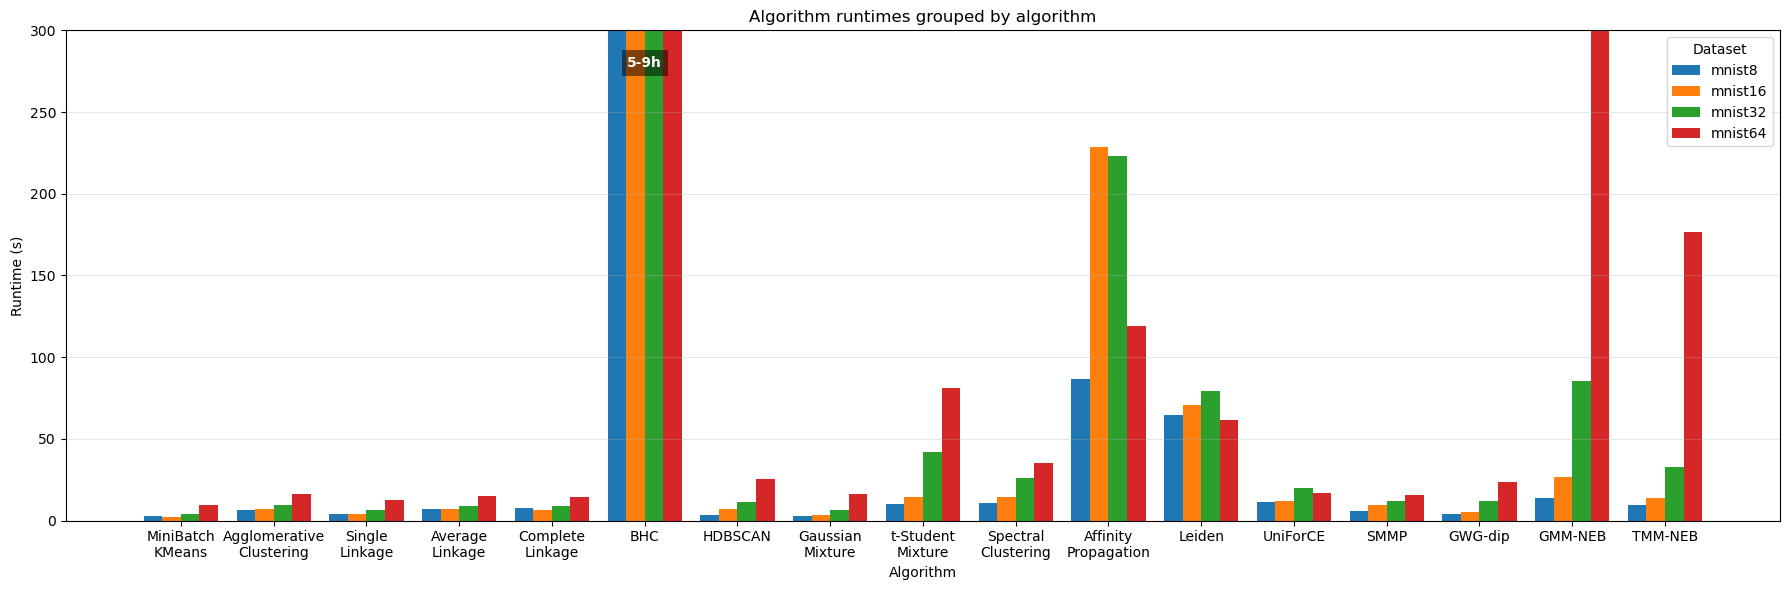

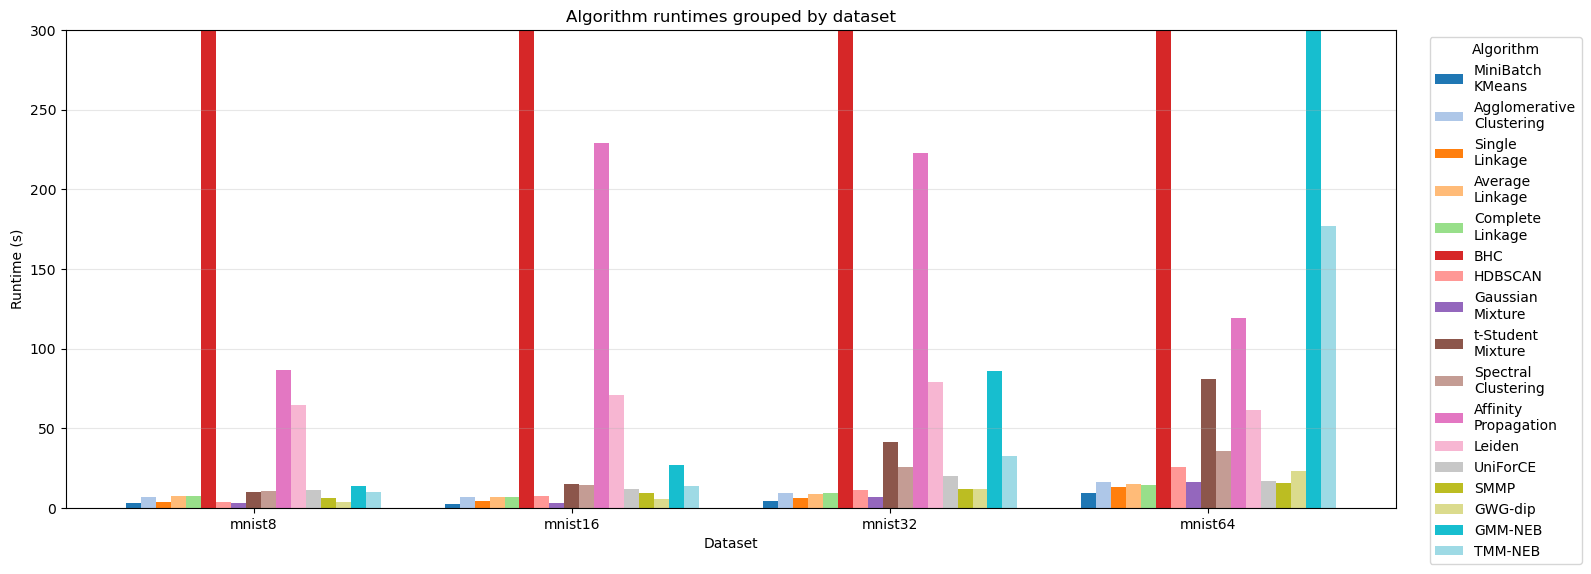

In [45]:
algo_names = list(algorithms)
dataset_names = list(datasets)

runtime_matrix = np.array([
    [all_runtimes.get(ds, {}).get(algo, np.nan) for algo in algo_names]
    for ds in dataset_names
], dtype=float)

# Plot 1: grouped by algorithm
x = np.arange(len(algo_names))
width = 0.8 / len(dataset_names)

fig, ax = plt.subplots(figsize=(18, 6))
for i, ds in enumerate(dataset_names):
    ax.bar(x + i * width - (len(dataset_names) - 1) * width / 2,
           runtime_matrix[i],
           width=width,
           label=ds)

ax.set_title("Algorithm runtimes grouped by algorithm")
ax.set_xlabel("Algorithm")
ax.set_ylabel("Runtime (s)")
ax.set_xticks(x)
ax.set_xticklabels(algo_names)

# Add BHC runtime range note directly at the BHC location.
if "BHC" in algo_names:
    bhc_x = algo_names.index("BHC")
    ax.text(bhc_x, 280, "5-9h", color="white", ha="center", va="center",
            fontweight="bold", bbox=dict(facecolor="black", alpha=0.5, edgecolor="none"))

ax.set_ylim(0, 300)
ax.legend(title="Dataset")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(cache_path, "../figures", "runtime_overview_grouped_by_algorithm.pdf"), bbox_inches='tight')
plt.show()

# Plot 2: grouped by dataset
x = np.arange(len(dataset_names))
width = 0.8 / len(algo_names)

fig, ax = plt.subplots(figsize=(16, 6))
colors = plt.cm.tab20(np.linspace(0, 1, len(algo_names)))

for j, algo in enumerate(algo_names):
    ax.bar(x + j * width - (len(algo_names) - 1) * width / 2,
           runtime_matrix[:, j],
           width=width,
           label=algo,
           color=colors[j])

ax.set_title("Algorithm runtimes grouped by dataset")
ax.set_xlabel("Dataset")
ax.set_ylabel("Runtime (s)")
ax.set_xticks(x)
ax.set_xticklabels(dataset_names)
ax.set_ylim(0, 300)
ax.legend(title="Algorithm", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(cache_path, "../figures", "runtime_overview_grouped_by_dataset.pdf"), bbox_inches='tight')
plt.show()

In [14]:
corc.utils.load_algorithms(dataset_name=dataset, algorithm="SpectralClustering", cache_path=cache_path, index=0)[0].runtime

25.959720134735107